In [1]:
import pickle, gzip
import numpy as np
import torch
import pandas
import time
import matplotlib.pyplot as plt
import glob
import random
import math
import os

In [2]:
#from ConvoLineNetwork import ConvoLineNetwork
from DCGAN import DCGAN
from Standardization import Standardization
from DigitDataset import DigitDataset
from DigitCollateFunction import collate_fn
import DataProcessing as DP
from os.path import expanduser

## MNIST Digit

In [3]:
home = os.path.expanduser('~')
data_fpath = home + '/myNotebooks/Notebooks_old/mnist.pkl.gz'

# Load the dataset
with gzip.open(data_fpath, 'rb') as f:
    train_set, valid_set, test_set = pickle.load(f, encoding='latin1')

In [4]:
Xtrain, Ttrain = train_set
Xvalid, Tvalid = valid_set
Xtest, Ttest = test_set 

img_channel = 1
wh = int(np.sqrt(Xtrain.shape[1] / img_channel))
Xtrain, Xvalid, Xtest = (x.reshape(-1, img_channel, wh, wh) for x in [Xtrain, Xvalid, Xtest])

st_obj = Standardization(Xtrain)

split_tuples_list = [(Xtrain, Ttrain), (Xvalid, Tvalid), (Xtest, Ttest)]

dataset_list = [DigitDataset(stup, st_obj) for stup in split_tuples_list]

batch_size_list = [32, 32, 32]
shuffle_list = [True, False, False]

trainloader, validloader, testloader = (torch.utils.data.DataLoader(dataset, 
                                                                    batch_size = batch_size, 
                                                                    collate_fn = collate_fn, 
                                                                    shuffle = shuffle) 
                                        for dataset, batch_size, shuffle 
                                        in zip(dataset_list, batch_size_list, shuffle_list))

In [5]:
n_noise = 100 # should I use a list for different noise for different models?

generator_kwargs_list = [{'n_units_in_conv_layers': [], 
                          'kernel_size_and_stride': [], 
                          'n_units_in_transpose_conv_layers': [], 
                          'transpose_kernel_size_and_stride': [],  
                          'n_units_in_fc_layers': [256, 256*2, 256*4], 
                          'inst_norm': False, 
                          'spec_norm': False,
                          'out_units': 28*28, 
                          'in_units': n_noise}, 
                        
                         {'n_units_in_conv_layers': [], 
                          'kernel_size_and_stride': [], 
                          'n_units_in_transpose_conv_layers': [], 
                          'transpose_kernel_size_and_stride': [],
                          'n_units_in_fc_layers': [256, 256*2, 256*4], 
                          'inst_norm': False, 
                          'spec_norm': False,
                          'out_units': 28*28, 
                          'in_units': n_noise}]

discriminator_kwargs_list = [{'n_units_in_conv_layers': [], 
                              'kernel_size_and_stride': [], 
                              'n_units_in_transpose_conv_layers': [], 
                              'transpose_kernel_size_and_stride': [],
                              'n_units_in_fc_layers': [1024, 1024//2, 1024//4], 
                              'inst_norm': False, 
                              'spec_norm': False,
                              'out_units': 1}, 
                             
                             {'n_units_in_conv_layers': [], 
                              'kernel_size_and_stride': [], 
                              'n_units_in_transpose_conv_layers': [], 
                              'transpose_kernel_size_and_stride': [],
                              'n_units_in_fc_layers': [1024, 1024//2, 1024//4], 
                              'inst_norm': False, 
                              'spec_norm': False,
                              'out_units': 1}]

In [8]:
evaluation_res_list = []

img_generated_list = []

train_error_trace_list = []
valid_error_trace_list = []
train_error_trace_discr_list = []
train_error_trace_gen_list = []
valid_error_trace_gen_list = []
train_end_error_discr_list = []
train_end_error_gen_list = []
valid_end_error_gen_list = []


in_channels = Xtrain.shape[1] 
width = Xtrain.shape[2]
height = Xtrain.shape[3]

use_gpu = True

n_gen = 40
n_gen_batch_size = 32

g_lr_list = [0.0001, 0.00001]
d_lr_list = [0.0001, 0.00001]
n_epochs_list = [2, 3]

best_vloss = None
states_path = './saved_states/mnist_gen_model_states.pth'

for generator_kwargs, discriminator_kwargs, g_lr, d_lr, n_epochs in zip(generator_kwargs_list, discriminator_kwargs_list, 
                                                                        g_lr_list, d_lr_list, n_epochs_list):

    print('|', end=' ')
    
    ganmodel = DCGAN(generator_kwargs, 
                     discriminator_kwargs, 
                     in_channels = in_channels, 
                     width = width, 
                     height = height, 
                     n_noise = n_noise, 
                     use_gpu = use_gpu)
    
    ganmodel.train(trainloader, validloader, g_lr = g_lr, d_lr = d_lr, n_epochs = n_epochs, best_vloss = best_vloss, states_path = states_path)
    best_vloss = ganmodel.get_best_validation_loss()
    
    train_error_trace, valid_error_trace = ganmodel.get_error_trace()
    train_error_trace_list.append(train_error_trace)
    valid_error_trace_list.append(valid_error_trace)

    train_error_trace_discr = [t[0] for t in train_error_trace]
    train_error_trace_gen = [t[1] for t in train_error_trace]
    train_error_trace_discr_list.append(train_error_trace_discr)
    train_error_trace_gen_list.append(train_error_trace_gen)
    
    valid_error_trace_gen = valid_error_trace
    valid_error_trace_gen_list.append(valid_error_trace_gen)

    train_end_error_discr = train_error_trace_discr[-1]
    train_end_error_discr_list.append(train_end_error_discr)
    train_end_error_gen = train_error_trace_gen[-1]
    train_end_error_gen_list.append(train_end_error_gen)

    valid_end_error_gen = valid_error_trace_gen[-1]
    valid_end_error_gen_list.append(valid_end_error_gen)

    img_generated = ganmodel.generate(n_gen = n_gen, batch_size = n_gen_batch_size)
    img_generated_list.append(img_generated)

    evaluation_res_list.append(ganmodel.evaluate(n_gen = n_gen, batch_size = n_gen_batch_size))
    

| | 

In [9]:
pandas.DataFrame([generator_kwargs_list, discriminator_kwargs_list, 
                  n_epochs_list, g_lr_list, d_lr_list, 
                  train_error_trace_gen_list, train_error_trace_discr_list, valid_error_trace_gen_list, evaluation_res_list], 
                 index = ['Gen Arch', 'Discr Arch', 'Epochs', 'Gen-lr', 'Discr-lr', 'Gen-Tr-loss', 'Discr-Tr-loss', 'Gen-Val-loss', 'Test-Acc']).T

,Gen Arch,Discr Arch,Epochs,Gen-lr,Discr-lr,Gen-Tr-loss,Discr-Tr-loss,Gen-Val-loss,Test-Acc
0,"{'n_units_in_conv_layers': [], 'kernel_size_an...","{'n_units_in_conv_layers': [], 'kernel_size_an...",2,0.0001,0.0001,"[4.001409153143565, 4.628951456328653]","[0.3978172493341807, 0.2869860808003363]","[5.214726472434144, 5.594028497275453]",0.0
1,"{'n_units_in_conv_layers': [], 'kernel_size_an...","{'n_units_in_conv_layers': [], 'kernel_size_an...",3,0.00001,0.00001,"[1.3507961308201077, 4.851506270129789, 5.5014...","[0.5511357696751944, 0.11214834384462884, 0.06...","[3.6267156844702773, 5.874282961836257, 5.2370...",0.0


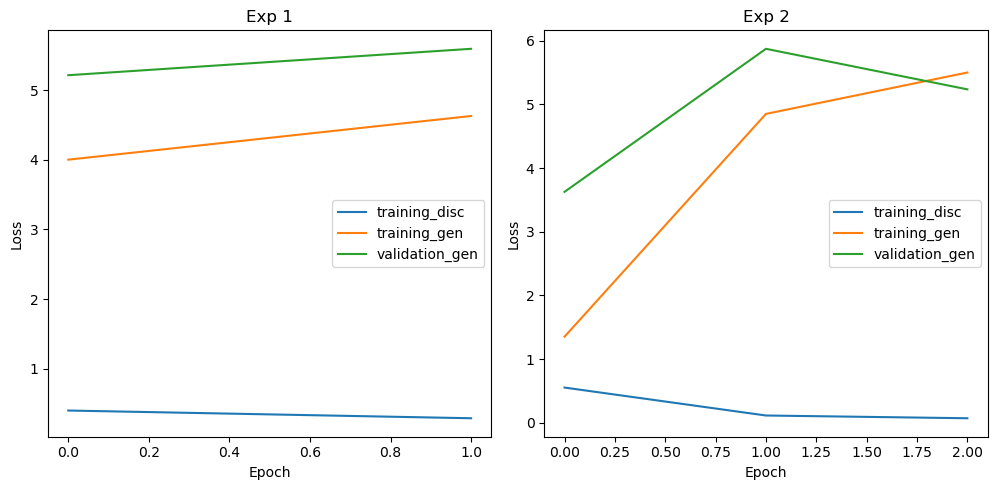

In [10]:
# The loss plots of the experiments. Fix the discr error and gen error according to the definition.

plt.figure(figsize = (20, 5))
n = len(n_epochs_list)
col = 4 #int(n/4)
row = math.ceil(n/col)
for i in range(n):
    plt.subplot(row, col, i+1)
    training_disc = train_error_trace_discr_list[i]
    training_gen = train_error_trace_gen_list[i]
    validation_gen = valid_error_trace_gen_list[i]
    plt.plot(training_disc, label = 'training_disc')
    plt.plot(training_gen, label = 'training_gen')
    plt.plot(validation_gen, label = 'validation_gen')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Exp {i+1}')
plt.tight_layout()

In [11]:
# Choose the network with better result, change anything needed, and train longer.

states_path = './saved_states/mnist_gen_model_states.pth'

checkpoint = torch.load(states_path)
#best_idx = np.argmax(evaluation_res_list)
best_args = checkpoint['model_args']
n_epochs = checkpoint['epoch']
loss_Fs = checkpoint['loss']

generator_kwargs, discriminator_kwargs, in_channels, width, height, n_noise, use_gpu = best_args

g_lr = 0.0001
d_lr = 0.0001
n_epochs = 100

# Specify a new path for saving the states of this trial.
best_vloss = None
states_path = './saved_states/mnist_gen_model_states_trial.pth'

ganmodel = DCGAN(generator_kwargs, 
                     discriminator_kwargs, 
                     in_channels = in_channels, 
                     width = width, 
                     height = height, 
                     n_noise = n_noise, 
                     use_gpu = use_gpu)
    
           
# Now either load the trained model's states and retrain (uncomment the following two lines)
ganmodel.generator.load_state_dict(checkpoint['model_state_dict']['generator'])
ganmodel.discriminator.load_state_dict(checkpoint['model_state_dict']['discriminator'])

ganmodel.train(trainloader, validloader, g_lr = g_lr, d_lr = d_lr, n_epochs = n_epochs, best_vloss = best_vloss, states_path = states_path)
best_vloss = ganmodel.get_best_validation_loss()
print(f'Best validation loss: {best_vloss:.3f}')

train_error_trace, valid_error_trace = ganmodel.get_error_trace()

train_error_trace_discr = [t[0] for t in train_error_trace]
train_error_trace_gen = [t[1] for t in train_error_trace]
valid_error_trace_gen = valid_error_trace

img_generated = ganmodel.generate(n_gen = n_gen, batch_size = n_gen_batch_size)
Test_acc = ganmodel.evaluate(n_gen = n_gen, batch_size = n_gen_batch_size)
print(f'Test Accuracy: {Test_acc:.3f}')

Best validation loss: 2.145
Test Accuracy: 0.000


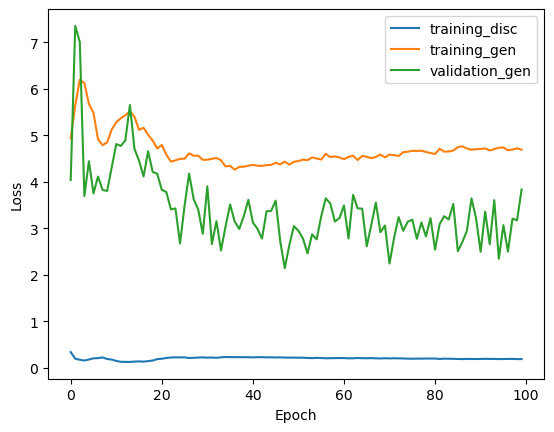

In [12]:
# Loss vs Epoch plot of the above trained model.

plt.plot(train_error_trace_discr, label = 'training_disc')
plt.plot(train_error_trace_gen, label = 'training_gen')
plt.plot(valid_error_trace_gen, label = 'validation_gen')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend();

In [13]:
# Best trained model's result

checkpoint = torch.load(states_path) #('dcgan_model_states.pth')

ganmodel_resume = DCGAN(*checkpoint['model_args'])

ganmodel_resume.generator.load_state_dict(checkpoint['model_state_dict']['generator'])
ganmodel_resume.discriminator.load_state_dict(checkpoint['model_state_dict']['discriminator'])

img_generated = ganmodel_resume.generate(n_gen = n_gen, batch_size = n_gen_batch_size) 
eval_result = ganmodel_resume.evaluate(n_gen = n_gen, batch_size = n_gen_batch_size)
print(eval_result)

0.05


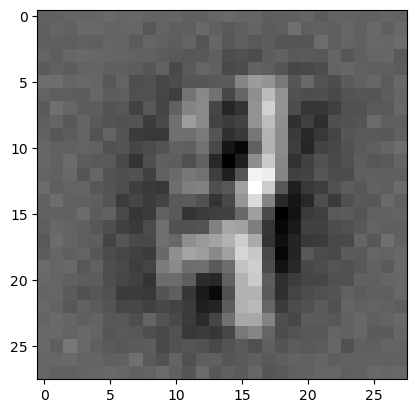

In [14]:
plt.imshow(img_generated[17, 0, :, :], cmap = 'grey');

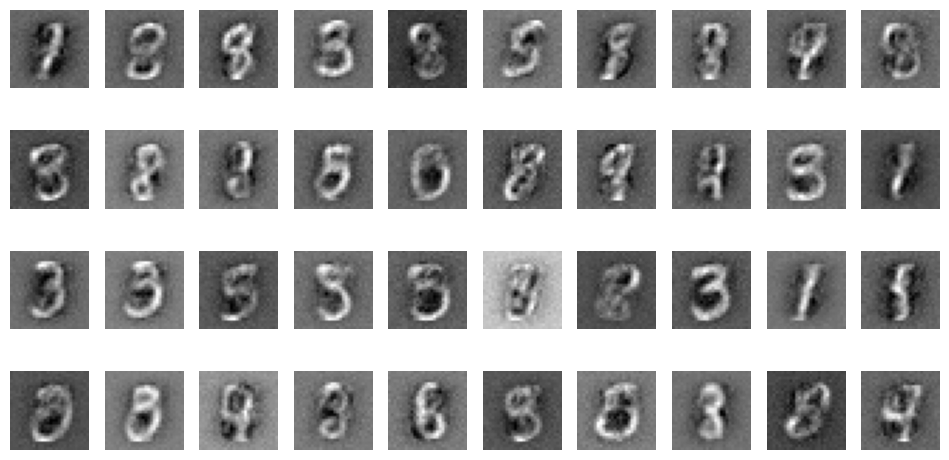

In [15]:
plt.figure(figsize = (12, 6))
n_cols = 10
n_rows = (n_gen // n_cols) + int(n_gen % n_cols != 0)
for i in range(img_generated.shape[0]):
    ax = plt.subplot(n_rows, n_cols, i+1)
    ax.imshow(img_generated[i, 0, :, :], cmap = 'grey');
    ax.axis(('off'))

In [16]:
# Use the preferred trained model to test on a different set of samples (rerun the dataloader cell to get a different set).
# Use either './saved_states//matrivasha_gen_model_states.pth' or './saved_states//matrivasha_gen_model_states_trial.pth'

reuse_states_path = './saved_states/mnist_gen_model_states_trial.pth'
checkpoint = torch.load(reuse_states_path)

ganmodel_reload = DCGAN(*checkpoint['model_args'])

ganmodel_reload.generator.load_state_dict(checkpoint['model_state_dict']['generator'])
ganmodel_reload.discriminator.load_state_dict(checkpoint['model_state_dict']['discriminator'])

img_generated_best = ganmodel_reload.generate(n_gen = n_gen, batch_size = n_gen_batch_size) 
eval_result = ganmodel_reload.evaluate(n_gen = n_gen, batch_size = n_gen_batch_size)
print(eval_result)

0.05


## Bengali compound letters generation

In [3]:
from DCGAN import DCGAN
from Standardization import Standardization
import DataProcessing as DP
from MatriVashaDataset import MatriVashaDataset
from MatriVashaCollateFunction import collate_fn
from os.path import expanduser

In [4]:
home = expanduser("~")
data_dir = home + '/Desktop/DataDir/Matrivasha/MatriVasha_Dataset'

In [5]:
data_list = ['/'.join(fname.split('/')[-3:]) for fname in glob.iglob(data_dir + '/**/*.jpg', recursive = True)]

In [6]:
data_np = np.array([plt.imread(fname) for fname in glob.iglob(data_dir + '/**/*.jpg', recursive = True)])

In [7]:
data_np.shape

(306464, 28, 28, 3)

In [8]:
random.shuffle(data_list)
np.random.shuffle(data_np)

In [9]:
n_train = int(len(data_list) * 0.2)
n_valid = int((len(data_list) - n_train) * 0.1)

Xtrain_list = data_list[:n_train]
Xvalid_list = data_list[n_train:n_train+n_valid]
Xtest_list = data_list[n_train+n_valid:n_train+n_valid+2000]

st_obj = Standardization(data_np.swapaxes(1, 3)[:n_train, ...])

split_tuples_list = [Xtrain_list, Xvalid_list, Xtest_list]

dataset_list = [MatriVashaDataset(data_dir, stup, st_obj) for stup in split_tuples_list]

batch_size_list = [128, 128, 128] # [32, 32, 32]
shuffle_list = [True, False, False]

trainloader, validloader, testloader = (torch.utils.data.DataLoader(dataset, 
                                                                    batch_size = batch_size, 
                                                                    collate_fn = collate_fn, 
                                                                    shuffle = shuffle) 
                                        for dataset, batch_size, shuffle 
                                        in zip(dataset_list, batch_size_list, shuffle_list))

In [10]:
len(Xtrain_list), len(Xvalid_list), len(Xtest_list)

(61292, 24517, 2000)

In [9]:
n_noise = 100 # should I use a list for different noise for different models?


generator_kwargs_list = [{'n_units_in_conv_layers': [], 
                          'kernel_size_and_stride': [], 
                          'n_units_in_transpose_conv_layers': [], #[32, 32], #[128, 128], 
                          'transpose_kernel_size_and_stride': [], #[[4, 2], [4, 2]],
                          'n_units_in_fc_layers': [256, 256*2, 256*4], 
                          'inst_norm': False, # True
                          'spec_norm': False, 
                          'out_units': 28*28*3, # 3
                          'in_units': n_noise}, 
                        
                         {'n_units_in_conv_layers': [], 
                          'kernel_size_and_stride': [], 
                          'n_units_in_transpose_conv_layers': [], #[32, 32], #[128, 128], 
                          'transpose_kernel_size_and_stride': [], #[[4, 2], [4, 2]],
                          'n_units_in_fc_layers': [256, 256*2, 256*4], 
                          'inst_norm': False, # True 
                          'spec_norm': False,
                          'out_units': 28*28*3, # 3
                          'in_units': n_noise}]

discriminator_kwargs_list = [{'n_units_in_conv_layers': [], #[16, 16], #[64, 64], 
                              'kernel_size_and_stride': [], #[[3, 2], [3, 2]], 
                              'n_units_in_transpose_conv_layers': [], 
                              'transpose_kernel_size_and_stride': [],
                              'n_units_in_fc_layers': [1024, 1024//2, 1024//4], # []
                              'inst_norm': False, # True
                              'spec_norm': False,
                              'out_units': 1}, 
                             
                             {'n_units_in_conv_layers': [], #[16, 16], #[64, 64], 
                              'kernel_size_and_stride': [], #[[3, 2], [3, 2]], 
                              'n_units_in_transpose_conv_layers': [], 
                              'transpose_kernel_size_and_stride': [],
                              'n_units_in_fc_layers': [1024, 1024//2, 1024//4], # []
                              'inst_norm': False, # True 
                              'spec_norm': False,
                              'out_units': 1}]

In [10]:
evaluation_res_list = []

img_generated_list = []

train_error_trace_list = []
valid_error_trace_list = []
train_error_trace_discr_list = []
train_error_trace_gen_list = []
valid_error_trace_gen_list = []
train_end_error_discr_list = []
train_end_error_gen_list = []
valid_end_error_gen_list = []

Xtrain = data_np.swapaxes(1, 3)
in_channels = Xtrain.shape[1] 
width = Xtrain.shape[2]
height = Xtrain.shape[3]

use_gpu = True

n_gen = 40
n_gen_batch_size = 32

g_lr_list = [0.0001, 0.00001]
d_lr_list = [0.0001, 0.00001]
n_epochs_list = [4, 5]

best_vloss = None
states_path = './saved_states/matrivasha_gen_model_states.pth'

for generator_kwargs, discriminator_kwargs, g_lr, d_lr, n_epochs in zip(generator_kwargs_list, discriminator_kwargs_list, 
                                                                        g_lr_list, d_lr_list, n_epochs_list):

    print('|', end = " ")
    
    ganmodel = DCGAN(generator_kwargs, 
                     discriminator_kwargs, 
                     in_channels = in_channels, 
                     width = width, 
                     height = height, 
                     n_noise = n_noise, 
                     use_gpu = use_gpu)
    
    ganmodel.train(trainloader, validloader, g_lr = g_lr, d_lr = d_lr, n_epochs = n_epochs, best_vloss = best_vloss, states_path = states_path)
    best_vloss = ganmodel.get_best_validation_loss()
    
    train_error_trace, valid_error_trace = ganmodel.get_error_trace()
    train_error_trace_list.append(train_error_trace)
    valid_error_trace_list.append(valid_error_trace)

    train_error_trace_discr = [t[0] for t in train_error_trace]
    train_error_trace_gen = [t[1] for t in train_error_trace]
    train_error_trace_discr_list.append(train_error_trace_discr)
    train_error_trace_gen_list.append(train_error_trace_gen)

    valid_error_trace_discr = [t[0] for t in valid_error_trace]
    valid_error_trace_gen = [t[1] for t in valid_error_trace] 
    #valid_error_trace_gen = valid_error_trace
    valid_error_trace_discr_list.append(valid_error_trace_discr)
    valid_error_trace_gen_list.append(valid_error_trace_gen)

    train_end_error_discr = train_error_trace_discr[-1]
    train_end_error_discr_list.append(train_end_error_discr)
    train_end_error_gen = train_error_trace_gen[-1]
    train_end_error_gen_list.append(train_end_error_gen)

    valid_end_error_discr = valid_error_trace_discr[-1]
    valid_end_error_discr_list.append(valid_end_error_discr)
    valid_end_error_gen = valid_error_trace_gen[-1]
    valid_end_error_gen_list.append(valid_end_error_gen)

    img_generated = ganmodel.generate(n_gen = n_gen, batch_size = n_gen_batch_size)
    img_generated_list.append(img_generated)

    evaluation_res_list.append(ganmodel.evaluate(n_gen = n_gen, batch_size = n_gen_batch_size))

| | 

In [11]:
pandas.DataFrame([generator_kwargs_list, discriminator_kwargs_list, n_epochs_list, g_lr_list, d_lr_list, 
                  train_end_error_gen_list, train_end_error_discr_list, valid_end_error_gen_list, valid_end_error_discr_list, 
                  evaluation_res_list], 
                 index = ['Gen Arch', 'Discr Arch', 'Epochs', 'Gen-lr', 'Discr-lr', 
                          'Gen-Tr-loss', 'Discr-Tr-loss', 'Gen-Val-loss', 'Discr-Val-loss', 'Test-Acc']).T

,Gen Arch,Discr Arch,Epochs,Gen-lr,Discr-lr,Gen-Tr-loss,Discr-Tr-loss,Gen-Val-loss,Test-Acc
0,"{'n_units_in_conv_layers': [], 'kernel_size_an...","{'n_units_in_conv_layers': [], 'kernel_size_an...",4,0.0001,0.0001,6.623282,0.106945,5.354889,0.0
1,"{'n_units_in_conv_layers': [], 'kernel_size_an...","{'n_units_in_conv_layers': [], 'kernel_size_an...",5,0.00001,0.00001,4.441173,0.029211,5.025196,0.0


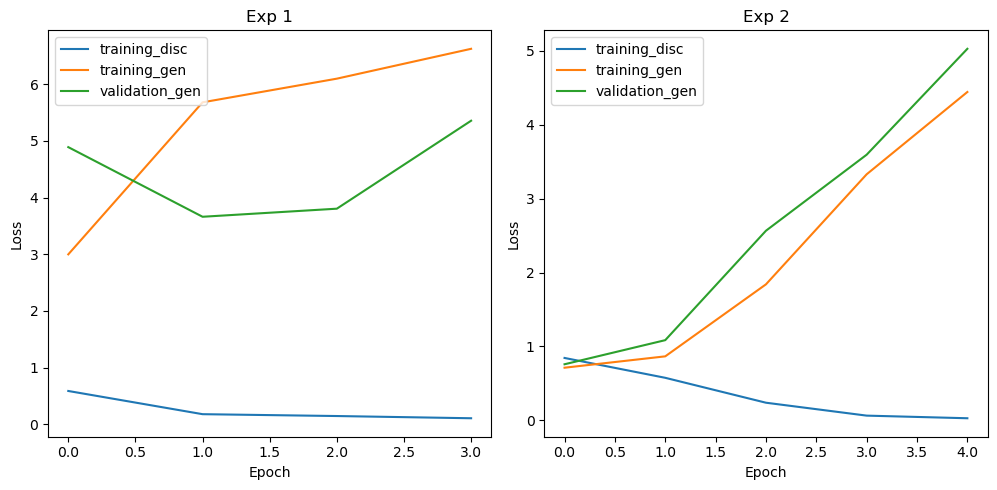

In [12]:
# The loss plots of the experiments.

plt.figure(figsize = (20, 5))
n = len(n_epochs_list)
col = 4 #int(n/4)
row = math.ceil(n/col)
for i in range(n):
    plt.subplot(row, col, i+1)
    training_disc = train_error_trace_discr_list[i]
    training_gen = train_error_trace_gen_list[i]
    validation_gen = valid_error_trace_gen_list[i]
    plt.plot(training_disc, label = 'training_disc')
    plt.plot(training_gen, label = 'training_gen')
    plt.plot(validation_gen, label = 'validation_gen')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Exp {i+1}')
plt.tight_layout()

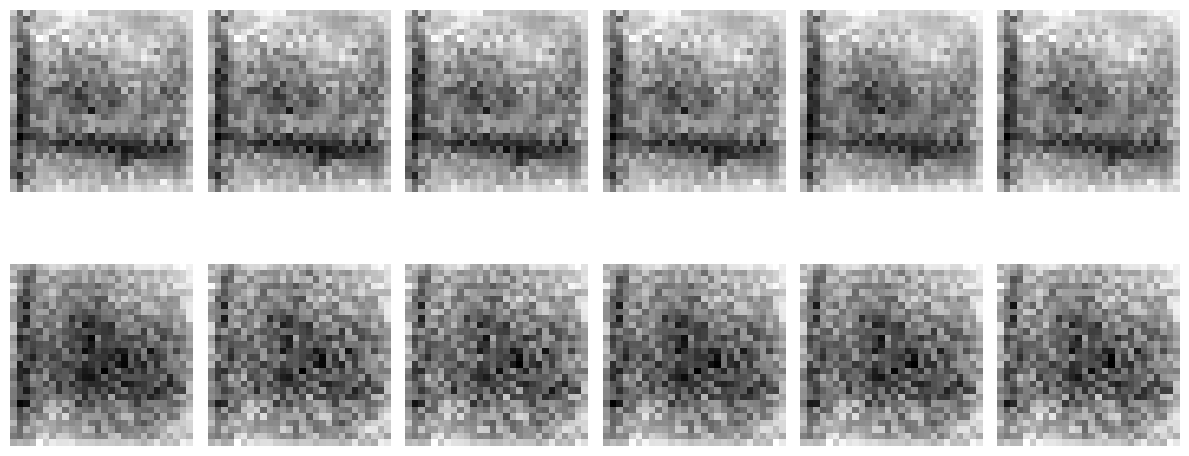

In [13]:
#img_generated_plot = img_generated_list[1]
n_imgs_per_model = 6
plt.figure(figsize = (12, 6))
n_cols = n_imgs_per_model # 10
n_rows = len(img_generated_list) # (n_gen // n_cols) + int(n_gen % n_cols != 0)
for i in range(n_rows):
    for j in range(n_cols):
        ax = plt.subplot(n_rows, n_cols, (i*n_cols) + j + 1)
        img_generated_plot = img_generated_list[i]
        img_generated_plot = st_obj._unstandardizeX(img_generated_plot)
        ax.imshow(img_generated_plot[j, 0, :, :], cmap = 'gray')
        ax.axis(('off'));
plt.tight_layout()

In [42]:
# Choose the network with better result, change anything needed, and train longer.

states_path = './saved_states/matrivasha_gen_model_states_trial.pth'  # _trial

checkpoint = torch.load(states_path)
#best_idx = np.argmax(evaluation_res_list)
best_args = checkpoint['model_args']
n_epochs = checkpoint['epoch']
learning_rate = checkpoint['loss']

generator_kwargs, discriminator_kwargs, in_channels, width, height, n_noise, use_gpu = best_args

#discriminator_kwargs['spec_norm'] = True

g_lr = 0.0001
d_lr = 0.0001
n_epochs = 20

# Specify a new path for saving the states of this trial.
best_vloss = None
states_path = './saved_states/matrivasha_gen_model_states_trial.pth'

ganmodel = DCGAN(generator_kwargs, 
                     discriminator_kwargs, 
                     in_channels = in_channels, 
                     width = width, 
                     height = height, 
                     n_noise = n_noise, 
                     use_gpu = use_gpu)
    
           
# Now either load the trained model's states and retrain (uncomment the following two lines)
ganmodel.generator.load_state_dict(checkpoint['model_state_dict']['generator'])
ganmodel.discriminator.load_state_dict(checkpoint['model_state_dict']['discriminator'])

ganmodel.train(trainloader, validloader, g_lr = g_lr, d_lr = d_lr, n_epochs = n_epochs, best_vloss = best_vloss, states_path = states_path)
best_vloss = ganmodel.get_best_validation_loss()
print(f'Best validation loss: {best_vloss:.3f}')

train_error_trace, valid_error_trace = ganmodel.get_error_trace()

train_error_trace_discr = [t[0] for t in train_error_trace]
train_error_trace_gen = [t[1] for t in train_error_trace]

valid_error_trace_discr = [t[0] for t in valid_error_trace]
valid_error_trace_gen = [t[1] for t in valid_error_trace] 

n_gen = 40
n_gen_batch_size = 32

img_generated = ganmodel.generate(n_gen = n_gen, batch_size = n_gen_batch_size)
Test_acc = ganmodel.evaluate(n_gen = n_gen, batch_size = n_gen_batch_size)
print(f'Test Accuracy: {Test_acc:.3f}')

Best validation loss: 0.227
Test Accuracy: 0.000


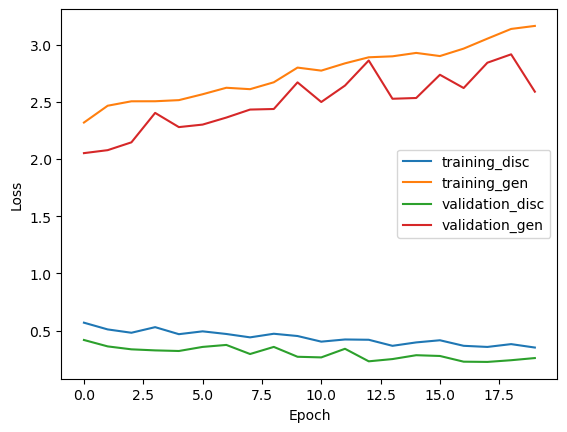

In [43]:
# Loss vs Epoch plot of the above trained model.

plt.plot(train_error_trace_discr, label = 'training_disc')
plt.plot(train_error_trace_gen, label = 'training_gen')
plt.plot(valid_error_trace_discr, label = 'validation_disc')
plt.plot(valid_error_trace_gen, label = 'validation_gen')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend();

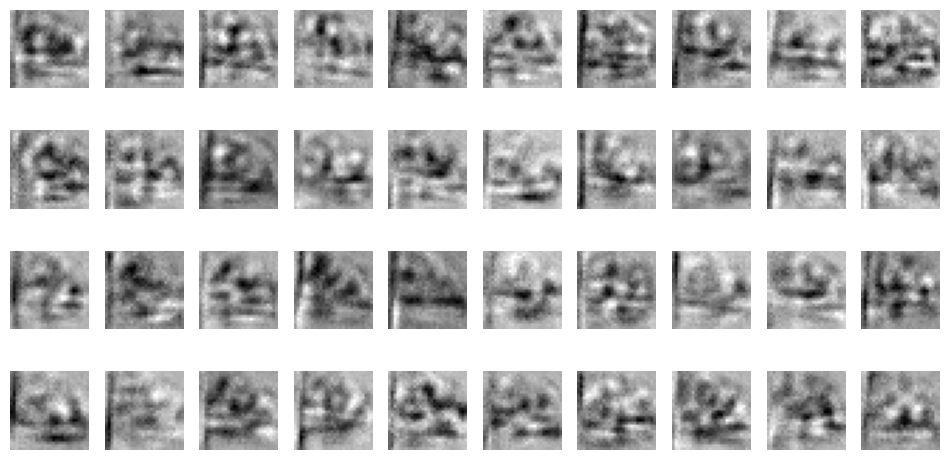

In [44]:
#img_generated_plot = img_generated_best
plt.figure(figsize = (12, 6))
n_cols = 10
n_rows = (n_gen // n_cols) + int(n_gen % n_cols != 0)
for i in range(img_generated.shape[0]):
    ax = plt.subplot(n_rows, n_cols, i+1)
    img_generated_uns = st_obj._unstandardizeX(img_generated)
    ax.imshow(img_generated_uns[i, 0, :, :], cmap = 'gray');
    ax.axis(('off'))

In [45]:
# Use the preferred trained model to test on a different set of samples (rerun the dataloader cell to get a different set).
# Use either './saved_states//matrivasha_gen_model_states.pth' or './saved_states//matrivasha_gen_model_states_trial.pth'

reuse_states_path = './saved_states/matrivasha_gen_model_states_trial.pth'
checkpoint = torch.load(reuse_states_path)

ganmodel_reload = DCGAN(*checkpoint['model_args'])

ganmodel_reload.generator.load_state_dict(checkpoint['model_state_dict']['generator'])
ganmodel_reload.discriminator.load_state_dict(checkpoint['model_state_dict']['discriminator'])

img_generated_best = ganmodel_reload.generate(n_gen = n_gen, batch_size = n_gen_batch_size) 
eval_result = ganmodel_reload.evaluate(n_gen = n_gen, batch_size = n_gen_batch_size)
print(eval_result)

0.0


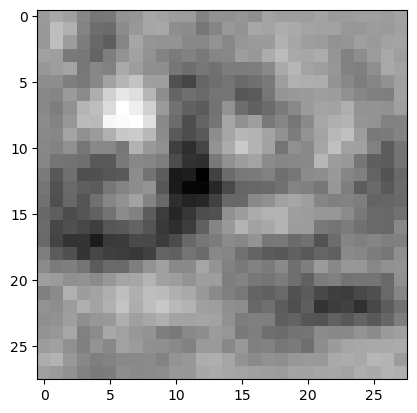

In [46]:
plt.imshow(img_generated_uns[17, 0, :, :], cmap = 'grey');

## Acknowledgements

1. https://medium.com/dejunhuang/learning-day-57-practical-5-loss-function-crossentropyloss-vs-bceloss-in-pytorch-softmax-vs-bd866c8a0d23
2. https://github.com/lyeoni/pytorch-mnist-GAN/blob/master/pytorch-mnist-GAN.ipynb
3. https://machinelearningmastery.com/how-to-develop-a-generative-adversarial-network-for-an-mnist-handwritten-digits-from-scratch-in-keras/
4. https://beckham.nz/2021/06/28/training-gans.html
5. https://www.reddit.com/r/deeplearning/comments/1aff9gd/interpreting_dcgan_results/